Fetching FRED Data...
Failed to fetch FRED data for GA
Failed to fetch FRED data for MA
Failed to fetch FRED data for NE
Saved 'raw_fred_data.csv'
Fetching Census Data...
Saved 'raw_census_data.csv'
Merging Datasets...

--- Summary Statistics ---
       Unemployment_Rate  Median_Income
count         192.000000     192.000000
mean            3.919575   67514.296875
std             1.100192   12165.458850
min             1.925000   44097.000000
25%             3.141667   58645.000000
50%             3.829167   65660.000000
75%             4.416667   75323.500000
max             7.350000  101027.000000

--- Correlation Analysis ---
Pearson Correlation (Linear): 0.049 (p-value: 0.4991)
Spearman Correlation (Monotonic): -0.021 (p-value: 0.7715)


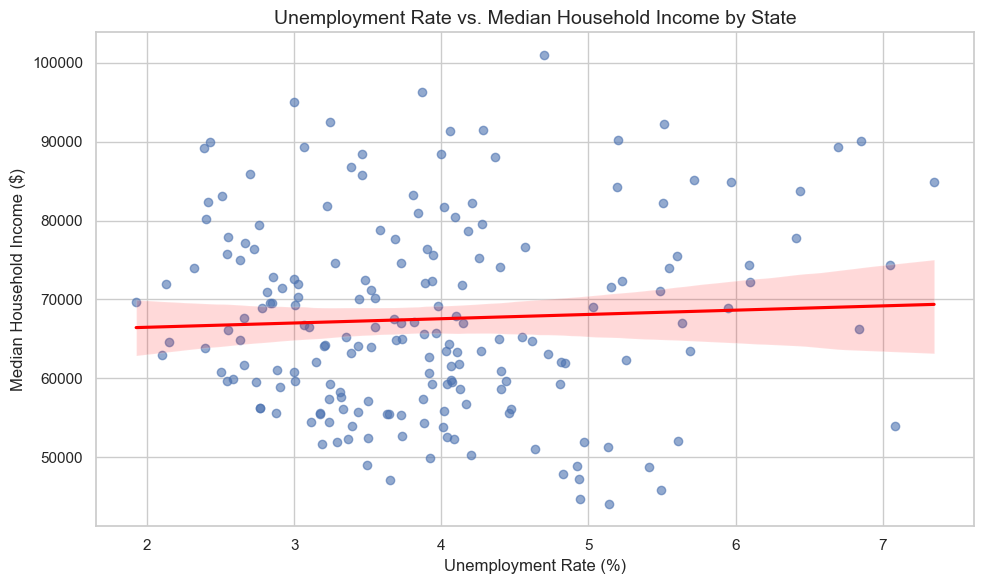

In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import time

#api keys
with open("fred_apikey.txt", "r") as f:
    FRED_API_KEY = f.read()
with open("census_apikey.txt", "r") as f:
    CENSUS_API_KEY = f.read()

STATES = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia'}
YEARS = [2018, 2019, 2021, 2022] # Skipping 2020


#API ACCESS: FRED state unemployment data
def get_fred_data(state_abbr, api_key):
    # use {State Abbreviation}UR (ex. CAUR)
    series_id = f"{state_abbr}UR"
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={api_key}&file_type=json"
    
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()['observations']
        df = pd.DataFrame(data)[['date', 'value']]
        df['State'] = state_abbr
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        return df
    else:
        print(f"Failed to fetch FRED data for {state_abbr}")
        return pd.DataFrame()

print("Fetching FRED Data...")
fred_dfs = []
for state in STATES.keys():
    fred_dfs.append(get_fred_data(state, FRED_API_KEY))
    time.sleep(0.5) # Be polite to the API

fred_df = pd.concat(fred_dfs, ignore_index=True)

#saving raw data
fred_df.to_csv('raw_fred_data.csv', index=False)
print("Saved 'raw_fred_data.csv'")

#CLEANING FRED DATA
fred_df['date'] = pd.to_datetime(fred_df['date'])
fred_df['Year'] = fred_df['date'].dt.year
#GROUPBY STATE AND YEAR
fred_annual = fred_df.groupby(['State', 'Year'])['value'].mean().reset_index()
fred_annual.rename(columns={'value': 'Unemployment_Rate'}, inplace=True)


#API ACCESS: U.S. Census i median household income by state (yearly)
def get_census_data(year, api_key):
    # B19013_001E is the variable for Median Household Income
    url = f"https://api.census.gov/data/{year}/acs/acs1?get=NAME,B19013_001E&for=state:*&key={api_key}"
    
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        headers = data.pop(0)
        df = pd.DataFrame(data, columns=headers)
        df['Year'] = year
        return df
    else:
        print(f"Failed to fetch Census data for {year}")
        return pd.DataFrame()

print("Fetching Census Data...")
census_dfs = []
for year in YEARS:
    census_dfs.append(get_census_data(year, CENSUS_API_KEY))
    time.sleep(0.5)

census_df = pd.concat(census_dfs, ignore_index=True)

#saving raw data
census_df.to_csv('raw_census_data.csv', index=False)
print("Saved 'raw_census_data.csv'")

#CLEANIG CENSUS DATA
census_df.rename(columns={'NAME': 'State_Name', 'B19013_001E': 'Median_Income'}, inplace=True)
census_df['Median_Income'] = pd.to_numeric(census_df['Median_Income'], errors='coerce')

# Schema matching (state names to abbreviations)
reverse_states = {v: k for k, v in STATES.items()}
census_df['State'] = census_df['State_Name'].map(reverse_states)
census_df.dropna(subset=['State'], inplace=True) # Drop states not in our target list

#MERGING DATASETS
print("Merging Datasets...")
# Merge on State abbreviation and Year
merged_df = pd.merge(fred_annual, census_df[['State', 'Year', 'Median_Income']], 
                     on=['State', 'Year'], 
                     how='inner')

# Drop missing values
merged_df.dropna(inplace=True)

#SUMMARY STATS
print("\n--- Summary Statistics ---")
print(merged_df[['Unemployment_Rate', 'Median_Income']].describe())

#CORRELATION ANALYSIS
print("\n--- Correlation Analysis ---")
# Pearson for linear
pearson_corr, p_value_p = pearsonr(merged_df['Unemployment_Rate'], merged_df['Median_Income'])
# Spearman for monotonic
spearman_corr, p_value_s = spearmanr(merged_df['Unemployment_Rate'], merged_df['Median_Income'])

print(f"Pearson Correlation (Linear): {pearson_corr:.3f} (p-value: {p_value_p:.4f})")
print(f"Spearman Correlation (Monotonic): {spearman_corr:.3f} (p-value: {p_value_s:.4f})")

#VISUALIZATION
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Scatter plot with a linear regression line
sns.regplot(
    data=merged_df, 
    x='Unemployment_Rate', 
    y='Median_Income', 
    scatter_kws={'alpha':0.6}, 
    line_kws={'color':'red'}
)

plt.title('Unemployment Rate vs. Median Household Income by State', fontsize=14)
plt.xlabel('Unemployment Rate (%)', fontsize=12)
plt.ylabel('Median Household Income ($)', fontsize=12)
plt.tight_layout()
plt.show()